In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

In [2]:
angry="C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Emotion_Detection/Angry/"

In [3]:
angry_names=os.listdir(angry)
len(angry_names)

491

In [4]:
fear="C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Emotion_Detection/Fear/"
fear

'C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Emotion_Detection/Fear/'

In [5]:
fear_names=os.listdir(fear)
len(fear_names)

528

In [6]:
happy="C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Emotion_Detection/Happy/"

In [7]:
happy_names=os.listdir(happy)
len(happy_names)

879

In [8]:
sad="C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Emotion_Detection/Sad/"

In [9]:
sad_names=os.listdir(sad)
len(sad_names)

594

In [10]:
surprise="C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Emotion_Detection/Surprise/"

In [11]:
surprise_names=os.listdir(surprise)
len(surprise_names)

416

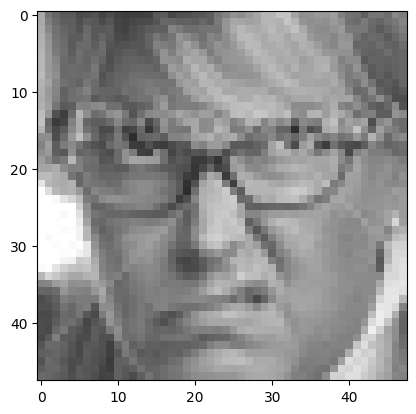

In [12]:
angry_1=cv2.imread(angry+angry_names[0])
plt.imshow(angry_1)

In [13]:
angry_1.shape

(48, 48, 3)

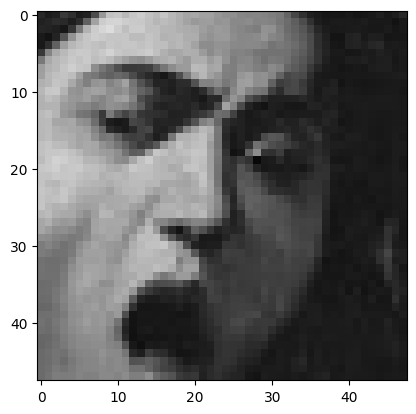

In [14]:
fear_1=cv2.imread(fear+fear_names[0])
plt.imshow(fear_1)

In [15]:
fear_1.shape

(48, 48, 3)

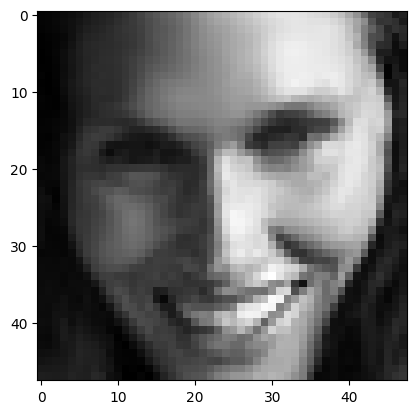

In [16]:
happy_1=cv2.imread(happy+happy_names[0])
plt.imshow(happy_1)

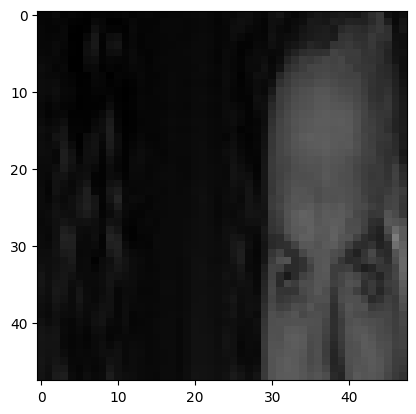

In [17]:
surprise_1=cv2.imread(surprise+surprise_names[0])
plt.imshow(surprise_1)

In [18]:
surprise_1.shape

(48, 48, 3)

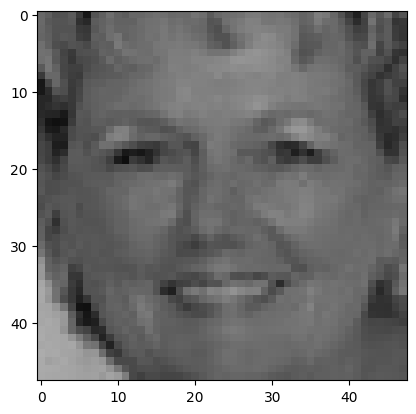

In [19]:
happy_2=cv2.imread(happy+happy_names[10])
plt.imshow(happy_2)

In [20]:
happy_2.shape

(48, 48, 3)

In [21]:
dataset=[]

In [22]:
labels=[]

In [23]:
for names in happy_names:
    h_img=cv2.imread(happy+names)
    h_img=np.array(h_img)
    dataset.append(h_img)
    labels.append(2)

In [24]:
len(dataset)

879

In [25]:
len(labels)

879

In [26]:
for names in sad_names:
    s_img=cv2.imread(sad+names)
    s_img=np.array(s_img)
    dataset.append(s_img)
    labels.append(1)


In [27]:
len(dataset)

1473

In [28]:
len(labels)

1473

In [29]:
for names in angry_names:
    a_img=cv2.imread(angry+names)
    a_img=np.array(a_img)
    dataset.append(a_img)
    labels.append(0)

In [30]:
len(dataset)

1964

In [31]:
for names in surprise_names:
    s_img=cv2.imread(surprise+names)
    s_img=np.array(s_img)
    dataset.append(s_img)
    labels.append(3)

In [32]:
len(dataset)

2380

In [33]:
len(labels)

2380

In [34]:
type(dataset)

list

In [35]:
ary_dataset=np.array(dataset)
ary_labels=np.array(labels)

In [36]:
x=ary_dataset.copy()
y=ary_labels.copy()

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=2)

In [38]:
x_train.shape

(1904, 48, 48, 3)

In [39]:
x_test.shape

(476, 48, 48, 3)

In [40]:
x_train.max()

np.uint8(255)

In [41]:
x_test.max()

np.uint8(255)

In [42]:
x_train_scale=x_train/255

In [43]:
x_test_scale=x_test/255

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Flatten,Dense
cnn=Sequential()

In [45]:
x_train.shape

(1904, 48, 48, 3)

In [46]:
cnn.add(Input(shape=(48,48,3)))
cnn.add(Conv2D(filters=32,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))
cnn.add(MaxPooling2D(pool_size=(2,2),padding="valid"))

In [47]:
cnn.add(Conv2D(filters=40,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))
cnn.add(MaxPooling2D(pool_size=(2,2),padding="valid"))

In [48]:
cnn.add(Flatten())
cnn.add(Dense(64,activation="relu"))
cnn.add(Dense(128,activation="relu"))
cnn.add(Dense(2565,activation="relu"))
cnn.add(Dense(4,activation="softmax"))

In [49]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 40)     │        11,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       256,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2565)           │       330,885 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │        10,264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,989 (2.36 MB)

 Trainable params: 617,989 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

In [51]:
cnn.fit(x_train_scale,y_train,epochs=5) 

Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.3676 - loss: 1.3591
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.3776 - loss: 1.3226
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4863 - loss: 1.1623
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5362 - loss: 1.0470
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5935 - loss: 0.9438


### 0-angry
### 1-sad
### 2-happy
### 3-surprise

In [52]:
p1=x_train_scale[200].reshape((1,)+x_train_scale[200].shape)

In [53]:
cnn.predict(p1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


array([[0.2085305 , 0.2069958 , 0.5401922 , 0.04428156]], dtype=float32)

In [54]:
np.argmax(cnn.predict(p1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


np.int64(2)

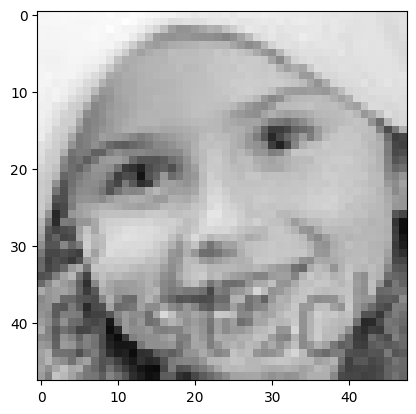

In [55]:
plt.imshow(x_train_scale[200])

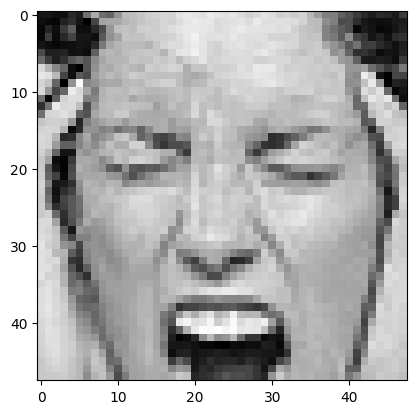

In [56]:
plt.imshow(x_test[200])

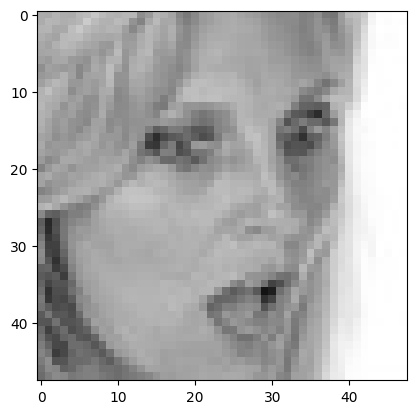

In [57]:
plt.imshow(x_train_scale[100])

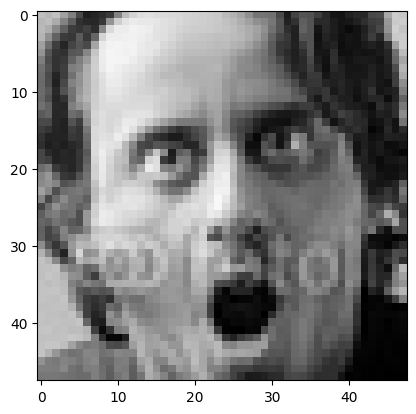

In [58]:
plt.imshow(x_test[100])

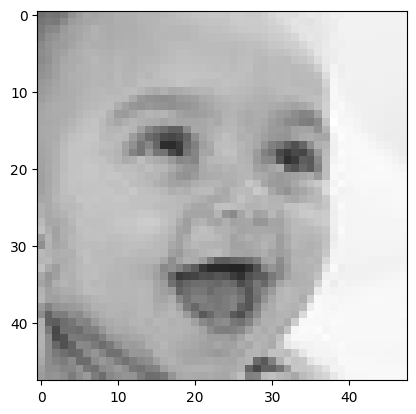

In [59]:
plt.imshow(x_train_scale[250])

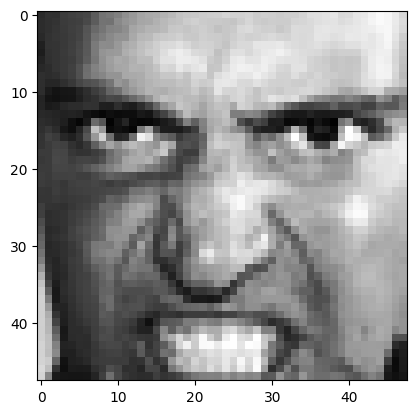

In [60]:
plt.imshow(x_test[250])

In [65]:
import re
usa=input("Enter usa number")
print(usa)
check=re.fullmatch("[0-9]{3}[-]{1}[0-9]{3}[-]{1}[0-9]{4}",usa)
print(check)

628-150-1830
<re.Match object; span=(0, 12), match='628-150-1830'>
